In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [80]:
import tensorflow

from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [81]:
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


#### Duplicate value Handling

In [83]:
df.duplicated().sum()

np.int64(0)

#### Data Balance Check

In [84]:
print(df['Exited'].value_counts())
print(df['Geography'].value_counts())
print(df['Gender'].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64
Gender
Male      5457
Female    4543
Name: count, dtype: int64


#### Feature Selection

In [85]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], inplace=True)

categorical = ["Geography", "Gender"]
numerical = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "HasCrCard",
    "IsActiveMember",
    "EstimatedSalary"
]

#### Train-Test Split

In [86]:
X = df.drop(columns=['Exited'])
y = df['Exited']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#### Data Preprocessing

In [87]:
perprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), categorical)
    ]
)

In [88]:
X_train = perprocessor.fit_transform(X_train)
X_test = perprocessor.transform(X_test)

#### Model Train

In [89]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

/Users/tanjimrahman/Deep Learning/02. MLP/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [90]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

In [91]:
model.compile(
    loss='binary_crossentropy',
    optimizer='Adam',
    metrics=['accuracy']
)

In [92]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [93]:
history = model.fit(
    X_train, y_train, 
    epochs=100, 
    validation_split=0.2,
    batch_size=32,
    callbacks=[early_stop])

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 893us/step - accuracy: 0.7914 - loss: 0.4818 - val_accuracy: 0.8388 - val_loss: 0.4190
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 551us/step - accuracy: 0.8353 - loss: 0.3942 - val_accuracy: 0.8544 - val_loss: 0.3717
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 533us/step - accuracy: 0.8480 - loss: 0.3650 - val_accuracy: 0.8625 - val_loss: 0.3484
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 540us/step - accuracy: 0.8545 - loss: 0.3505 - val_accuracy: 0.8706 - val_loss: 0.3386
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.8558 - loss: 0.3423 - val_accuracy: 0.8744 - val_loss: 0.3330
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 493us/step - accuracy: 0.8559 - loss: 0.3383 - val_accuracy: 0.8694 - val_loss: 0.3347
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.8611 - loss: 0.3342 - val_accuracy: 0.8700 - val_loss: 0.3322
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 494us/step - accuracy: 0.8616 - loss: 0

In [108]:
y_log = model.predict(X_test)
y_pred = np.where(y_log>0.5, 1, 0)
y_pred_prob = model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 425us/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 309us/step


#### Model Evaluation

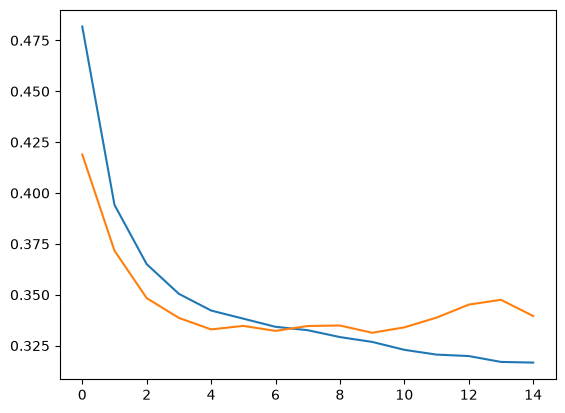

In [98]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

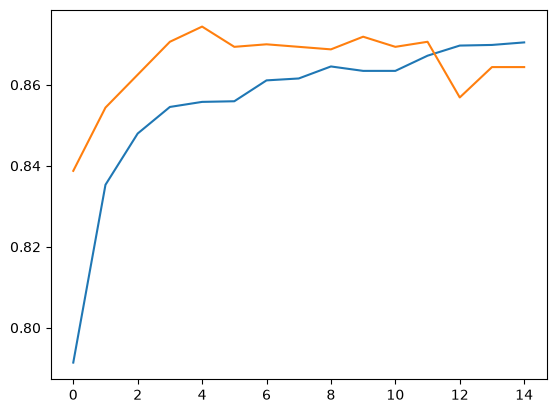

In [99]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

In [100]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 488us/step - accuracy: 0.8640 - loss: 0.3468
Test Loss: 0.34675467014312744
Test Accuracy: 0.8640000224113464


#### Result Analysis

In [104]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

# TN FP
# FN TP

[[1544   49]
 [ 223  184]]


<Axes: >

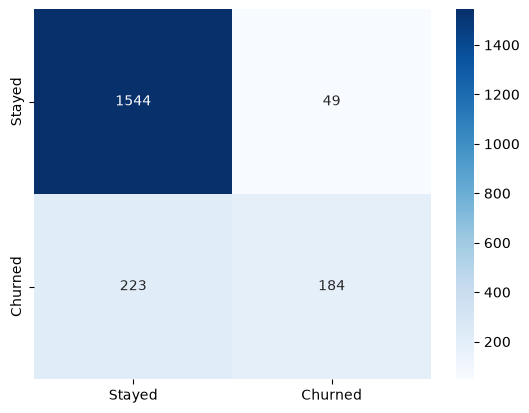

In [105]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Stayed", "Churned"],
    yticklabels=["Stayed", "Churned"]
)

In [107]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Stayed", "Churned"]
))

              precision    recall  f1-score   support

      Stayed       0.87      0.97      0.92      1593
     Churned       0.79      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.86      0.85      2000



In [109]:
from sklearn.metrics import precision_score, recall_score, f1_score

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6]:
    y_pred_threshold = (y_pred_prob >= threshold).astype(int)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    print(
        f"Threshold: {threshold:.1f} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.2 | Precision: 0.49 | Recall: 0.71 | F1: 0.58
Threshold: 0.3 | Precision: 0.62 | Recall: 0.61 | F1: 0.62
Threshold: 0.4 | Precision: 0.71 | Recall: 0.53 | F1: 0.61
Threshold: 0.5 | Precision: 0.79 | Recall: 0.45 | F1: 0.57
Threshold: 0.6 | Precision: 0.84 | Recall: 0.35 | F1: 0.49


In [111]:
auc = roc_auc_score(y_test, y_pred_prob)
print("ROC-AUC:", auc)

ROC-AUC: 0.852166496234293


#### Decision Making

| Metric | Result |
|---|---:|
| Test Loss | 0.3468 |
| Test Accuracy | 86.40% |
| ROC-AUC | 0.8522 |
| Churn Precision (0.5) | 79% |
| Churn Recall (0.5) | 45% |
| Churn F1-Score (0.5) | 57% |
| Churn Precision (0.3) | 62% |
| Churn Recall (0.3) | 61% |
| Churn F1-Score (0.3) | 62% |

The default threshold of 0.5 provides higher precision (79%) but detects only 45% of actual churners. Lowering the threshold to 0.3 improves churn recall to 61% and F1-score to 62%, providing a better balance between identifying churners and limiting false positives. Therefore, a threshold of 0.3 would be preferred if detecting potential churners is the primary business objective.